In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ALL_SAHAM_RELEVANCY_NEWS.csv")
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['year'] = df['tanggal'].dt.year
df_eda = df[(df['year'] >= 2022) & (df['year'] <= 2024)]

print(df_eda['year'].value_counts().sort_index())


year
2022    3580
2023    3287
2024    3781
Name: count, dtype: int64


In [ ]:
df.head()

,Unnamed: 0,tanggal,kategori,judul,url,konten_clean,year
0,0,2022-01-05,ekonomi,"Soroti Minyak Goreng Mahal, Ma'ruf Amin: Janga...",https://finance.detik.com/berita-ekonomi-bisni...,harga minyak goreng sorot publik lantar harga...,2022
1,1,2022-01-05,ekonomi,"Lagi Terbelit Utang, Evergrande Disuruh Hancur...",https://finance.detik.com/properti/d-5885844/l...,selesai utang kembang properti china evergran...,2022
2,3,2022-01-05,ekonomi,Sri Mulyani Kasih Tugas Khusus ke Bos Baru LPE...,https://finance.detik.com/moneter/d-5885624/sr...,lembaga biaya ekspor indonesia lpei milik ke...,2022
3,4,2022-01-05,ekonomi,Perbankan Tak Bisa Mendadak Setop Biayai Batu ...,https://finance.detik.com/energi/d-5885790/per...,sektor uang perban arah dukung terap ekonomi h...,2022
4,5,2022-01-05,ekonomi,Harapan Jokowi Resmikan Pasar Johar: Ekonomi R...,https://finance.detik.com/berita-ekonomi-bisni...,presiden joko widodo resmi pasar johar kota se...,2022


# Distribusi Jumlah Berita per Tahun (2022-2024)

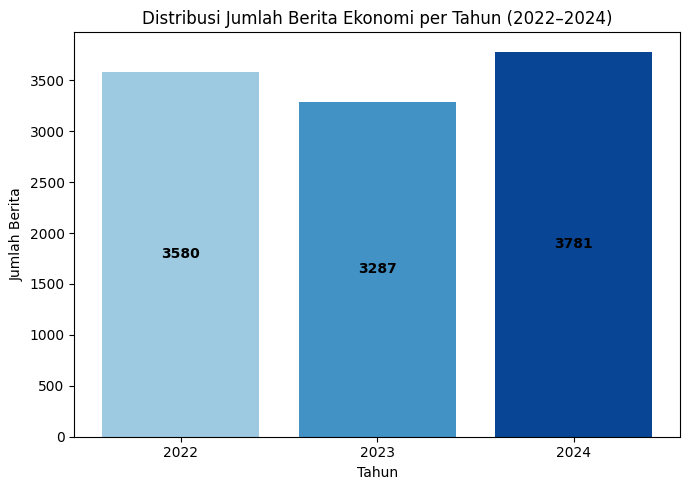

In [ ]:
news_per_year = df_eda['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    news_per_year.index.astype(str),
    news_per_year.values,
    color = ['#9ecae1', '#4292c6', '#084594']
)

ax.set_xlabel("Tahun")
ax.set_ylabel("Jumlah Berita")
ax.set_title("Distribusi Jumlah Berita Ekonomi per Tahun (2022–2024)")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f'{int(height)}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


# Analisis Frekuensi Kata & Word Cloud

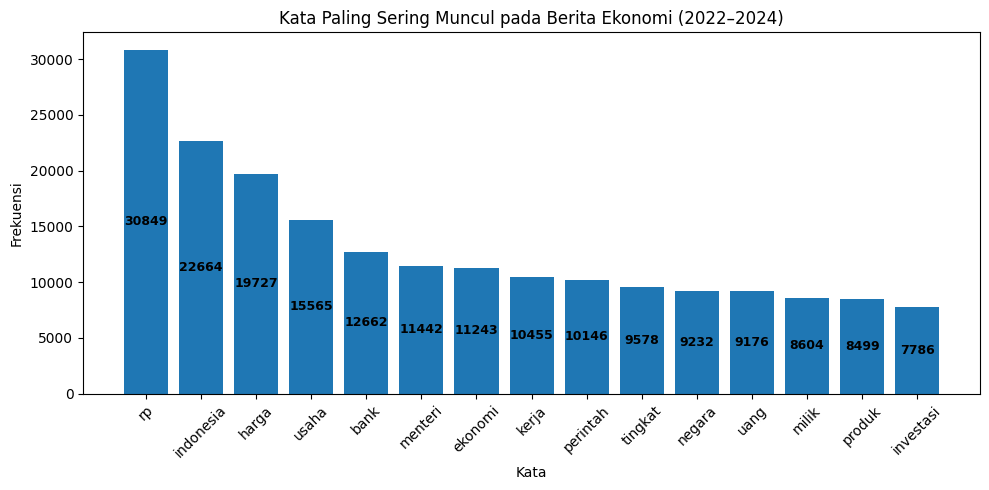

In [ ]:
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt

text = " ".join(df_eda['konten_clean'].dropna().astype(str))

text = text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)

words = text.split()
word_freq = Counter(words)

common_words = word_freq.most_common(15)
freq_df = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(freq_df['Kata'], freq_df['Frekuensi'])

ax.set_xlabel("Kata")
ax.set_ylabel("Frekuensi")
ax.set_title("Kata Paling Sering Muncul pada Berita Ekonomi (2022–2024)")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f'{int(height)}',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

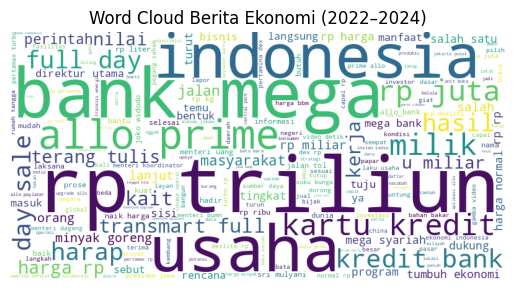

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud Berita Ekonomi (2022–2024)")
plt.show()


# Distribusi Sentimen per Tahun

In [ ]:
df_sentimen = pd.read_csv("df_sentiment_saham_final.csv")
df_sentimen.head()

,tanggal,kategori,judul,url,konten_clean,sentiment_label,sentiment_score
0,2022-01-05,ekonomi,"Soroti Minyak Goreng Mahal, Ma'ruf Amin: Janga...",https://finance.detik.com/berita-ekonomi-bisni...,harga minyak goreng sorot publik lantar harga...,positif,1.000000
1,2022-01-05,ekonomi,"Lagi Terbelit Utang, Evergrande Disuruh Hancur...",https://finance.detik.com/properti/d-5885844/l...,selesai utang kembang properti china evergran...,negatif,1.000000
2,2022-01-05,ekonomi,Sri Mulyani Kasih Tugas Khusus ke Bos Baru LPE...,https://finance.detik.com/moneter/d-5885624/sr...,lembaga biaya ekspor indonesia lpei milik ke...,positif,0.715069
3,2022-01-05,ekonomi,Perbankan Tak Bisa Mendadak Setop Biayai Batu ...,https://finance.detik.com/energi/d-5885790/per...,sektor uang perban arah dukung terap ekonomi h...,negatif,1.000000
4,2022-01-05,ekonomi,Harapan Jokowi Resmikan Pasar Johar: Ekonomi R...,https://finance.detik.com/berita-ekonomi-bisni...,presiden joko widodo resmi pasar johar kota se...,positif,0.896946


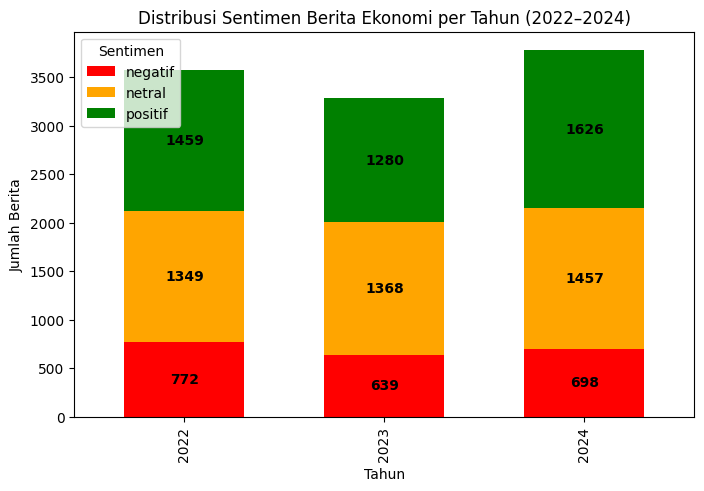

In [ ]:
sentiment_year = (
    df_sentimen
    .groupby([df['year'], 'sentiment_label'])
    .size()
    .unstack()
)

ax = sentiment_year.plot(
    kind='bar',
    stacked=True,
    color=['red', 'orange', 'green'],
    figsize=(8, 5),
    width=0.6
)

plt.xlabel("Tahun")
plt.ylabel("Jumlah Berita")
plt.title("Distribusi Sentimen Berita Ekonomi per Tahun (2022–2024)")
plt.legend(title="Sentimen", loc=0)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fontsize=10,
        fontweight='bold'
    )


plt.show()